In [1]:
# Step 0: Install and import necessary libraries (Colab already has most installed)
!pip install scikit-learn matplotlib seaborn --quiet

In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files  # For uploading dataset in Colab
from matplotlib.colors import ListedColormap

In [4]:
# Step 2: Upload Dataset from Local Disk
# "Choose Files" and select their iris.csv
uploaded = files.upload()

# Load and read the dataset
data = pd.read_csv("Iris.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
print(data.head())

Saving Iris.csv to Iris (1).csv
First 5 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
# Step 3: Explain Dataset
print("\nColumns / Features:", list(data.columns))
print("Rows / Samples:", data.shape[0])
print("Target variable / Class labels: species")



Columns / Features: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Rows / Samples: 150
Target variable / Class labels: species


In [8]:
# Step 4: Encode Target Variable
# 'species' is categorical; convert to numeric
label_encoder = LabelEncoder()
data['species_encoded'] = label_encoder.fit_transform(data['Species'])
print("\nClass labels after encoding:")
print(data[['Species', 'species_encoded']].drop_duplicates())


Class labels after encoding:
             Species  species_encoded
0        Iris-setosa                0
50   Iris-versicolor                1
100   Iris-virginica                2


In [10]:
# Step 5: Check for Missing Values
print("\nChecking for missing values:")
print(data.isnull().sum())
# If missing values exist, fill with column mean (simple strategy)
# Calculate mean only for numeric columns
numeric_means = data.select_dtypes(include=np.number).mean()
data.fillna(numeric_means, inplace=True)
print("\nMissing values after attempted filling:")
print(data.isnull().sum())


Checking for missing values:
Id                 0
SepalLengthCm      0
SepalWidthCm       0
PetalLengthCm      0
PetalWidthCm       0
Species            0
species_encoded    0
dtype: int64

Missing values after attempted filling:
Id                 0
SepalLengthCm      0
SepalWidthCm       0
PetalLengthCm      0
PetalWidthCm       0
Species            0
species_encoded    0
dtype: int64


In [14]:
# ------------------------------------------------------
# Step 6: Select Features (Use 2 for plotting)
# ------------------------------------------------------
X = data[['PetalLengthCm', 'PetalWidthCm']]  # 2D features for visualization
y = data['species_encoded']

In [15]:
# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 120, Testing samples: 30


In [16]:
# Step 8: Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3)  # k = 3
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [22]:
# Training performance
y_train_pred = knn.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='macro')
train_rec = recall_score(y_train, y_train_pred, average='macro')

print("Training Performance:")
print(f"Accuracy: {train_acc:.2f}, Precision: {train_prec:.2f}, Recall: {train_rec:.2f}")

Training Performance:
Accuracy: 0.97, Precision: 0.98, Recall: 0.97


In [25]:
# Pick a test sample
sample = X_test.iloc[0].values.reshape(1, -1)
distances, indices = knn.kneighbors(sample, n_neighbors=3)

print("Test sample:", sample)
print("Distances to 3 nearest neighbors:", distances)
print("Indices of nearest neighbors:", indices)
print("Neighbor classes:", y_train.iloc[indices[0]].values)
print("Predicted class (majority vote):", knn.predict(sample)[0])

Test sample: [[1.3 0.2]]
Distances to 3 nearest neighbors: [[0.  0.  0.1]]
Indices of nearest neighbors: [[116  60   0]]
Neighbor classes: [0 0 0]
Predicted class (majority vote): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [17]:
# Step 9: Predict and Evaluate
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f"\nKNN Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


KNN Performance:
Accuracy: 0.97
Precision: 0.97
Recall: 0.97


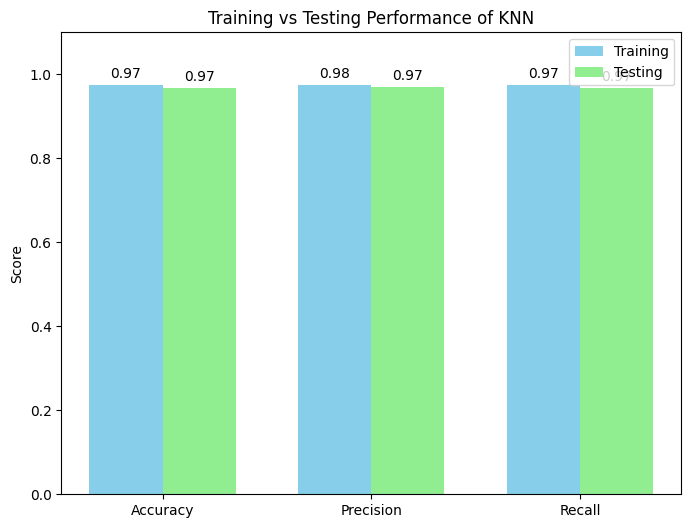

In [23]:
import matplotlib.pyplot as plt

# Suppose you already calculated these:
# Training performance
train_acc = accuracy_score(y_train, knn.predict(X_train))
train_prec = precision_score(y_train, knn.predict(X_train), average='macro')
train_rec = recall_score(y_train, knn.predict(X_train), average='macro')

# Testing performance
test_acc = accuracy_score(y_test, knn.predict(X_test))
test_prec = precision_score(y_test, knn.predict(X_test), average='macro')
test_rec = recall_score(y_test, knn.predict(X_test), average='macro')

# Create a dictionary of metrics
metrics = ['Accuracy', 'Precision', 'Recall']
training_scores = [train_acc, train_prec, train_rec]
testing_scores = [test_acc, test_prec, test_rec]

# Plot side-by-side bar chart
x = np.arange(len(metrics))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width/2, training_scores, width, label='Training', color='skyblue')
rects2 = ax.bar(x + width/2, testing_scores, width, label='Testing', color='lightgreen')

# Add labels and title
ax.set_ylabel('Score')
ax.set_title('Training vs Testing Performance of KNN')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# Add text labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()

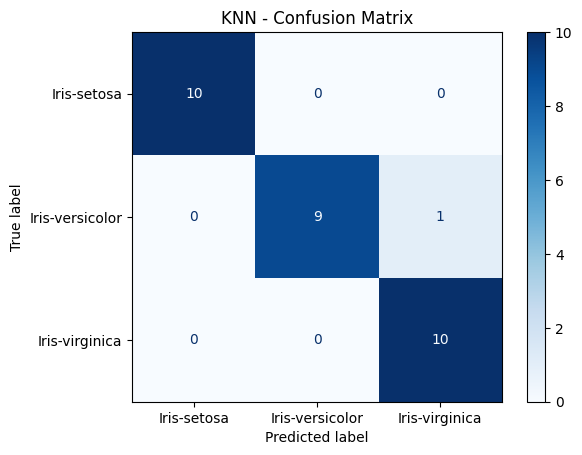

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("KNN - Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


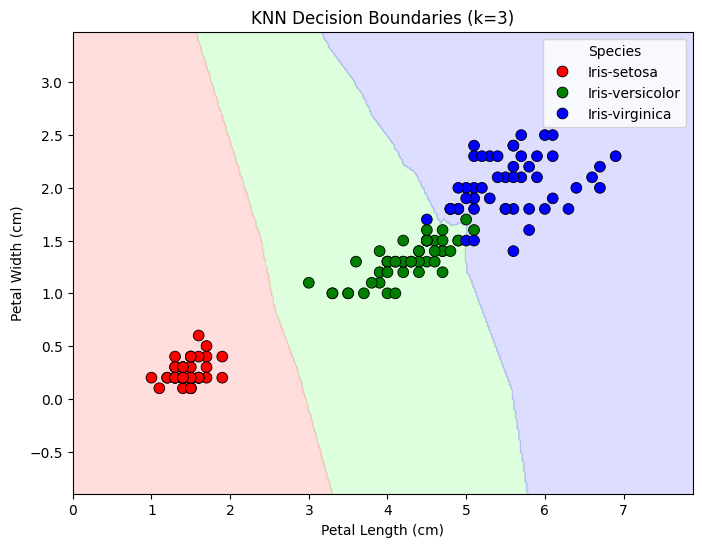

In [24]:
# Step 10: Plot Decision Boundaries to Show How KNN Works
# Create a mesh grid
h = 0.02  # step size in the mesh
x_min, x_max = X['PetalLengthCm'].min() - 1, X['PetalLengthCm'].max() + 1
y_min, y_max = X['PetalWidthCm'].min() - 1, X['PetalWidthCm'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define color map
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Plot decision boundaries
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)

# Plot training points
sns.scatterplot(x=X['PetalLengthCm'], y=X['PetalWidthCm'], hue=data['Species'],
                palette=['red','green','blue'], s=60, edgecolor='k')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('KNN Decision Boundaries (k=3)')
plt.show()

In [26]:
# Example new unseen data
new_sample = pd.DataFrame([[5.0, 1.5]],
                          columns=['PetalLengthCm', 'PetalWidthCm'])

prediction = knn.predict(new_sample)[0]
predicted_class = label_encoder.inverse_transform([prediction])[0]

print("New Sample:", new_sample.values)
print("Predicted class:", predicted_class)

New Sample: [[5.  1.5]]
Predicted class: Iris-virginica


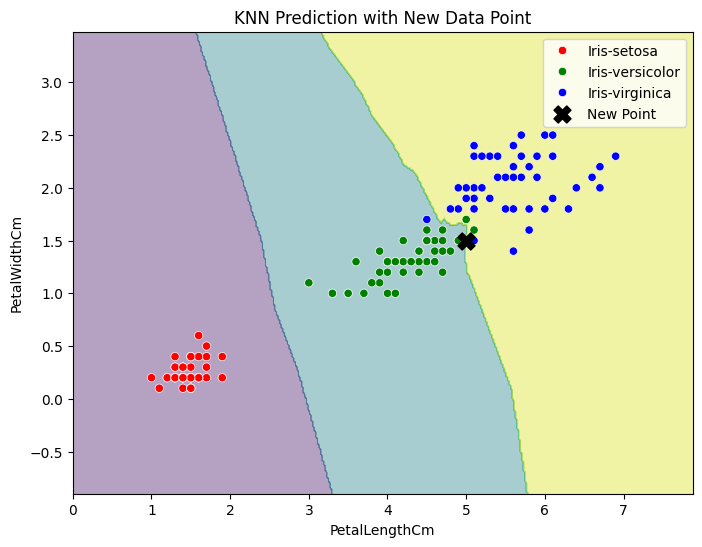

In [28]:
plt.figure(figsize=(8,6))

# Decision boundary
plt.contourf(xx, yy, Z, alpha=0.4)

# Original data
sns.scatterplot(x=X['PetalLengthCm'], y=X['PetalWidthCm'],
                hue=data['Species'], palette=['red','green','blue'])

# New point coordinates
petal_length = new_sample['PetalLengthCm'].iloc[0]
petal_width = new_sample['PetalWidthCm'].iloc[0]
plt.scatter(petal_length, petal_width, color='black', s=150, marker='X', label='New Point')

plt.legend()
plt.title("KNN Prediction with New Data Point")
plt.show()